In [5]:
from functools import partial
from typing import Union

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  # Useful dataclass to keep train state
from jax.tree import map as tree_map
from matplotlib import pyplot as plt
from tqdm import tqdm

exp

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

from run_pinns import *

In [6]:
num_interior = 80 * 8
num_boundary = 20 * 8
interior_points, boundary_points = generate_training_data(num_interior, num_boundary)


In [7]:
dims = 256
model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=1e-3, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

n, m = 1, 1
state, metrics_history_sgd_11 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=10000,
                                     lm_schedule=None,
                                     forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                         m * jnp.pi * x[1]),
                                     batch_size=200
                                     )


model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=1e-3, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

n, m = 2, 2
state, metrics_history_sgd_22 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=10000,
                                     lm_schedule=None,
                                     forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                        m * jnp.pi * x[1]),
                                     batch_size=200
                                     )

model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=1e-3, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

n, m = 3, 3
state, metrics_history_sgd_33 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=10000,
                                     lm_schedule=None,
                                     forcing_function=lambda x: (n ** 2 + m ** 2)  * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                         m * jnp.pi * x[1]),
                                     batch_size=200
                                     )


  0%|                                                                                    | 1/10000 [00:00<1:35:31,  1.74it/s, loss=2.3454]

(160, 2) (40, 2)


  0%|▏                                                                                  | 23/10000 [00:00<01:26, 115.13it/s, loss=62.9296]

(160, 2) (40, 2)


  0%|                                                                                    | 1/10000 [00:00<24:11,  6.89it/s, loss=670.3445]

(160, 2) (40, 2)


100%|█████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:46<00:00, 214.28it/s, loss=2.3884]


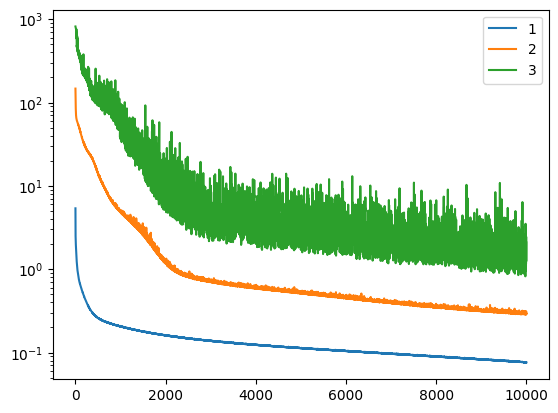

In [8]:
plt.semilogy(metrics_history_sgd_11['train_loss'])
plt.semilogy(metrics_history_sgd_22['train_loss'])
plt.semilogy(metrics_history_sgd_33['train_loss'])
plt.legend(['1', '2', '3'])
plt.show()


In [9]:
model = MLP_1D(
    1, dims
)

lr = 2e-2
state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
    # method='gn-exact', epoch=0
)


model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

n, m = 3, 3
state, metrics_history_smw_33 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=4000,
                                     lm_schedule=lm_info,
                                     forcing_function=lambda x: (n ** 2 + m ** 2)  * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                         m * jnp.pi * x[1]),
                                     batch_size=200
                                     )

n, m = 1, 1
state, metrics_history_smw_11 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=4000,
                                     lm_schedule=lm_info,
                                     forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                         m * jnp.pi * x[1]),
                                     batch_size=200
                                     )

model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

n, m = 2, 2
state, metrics_history_smw_22 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=4000,
                                     lm_schedule=lm_info,
                                     forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                        m * jnp.pi * x[1]),
                                     batch_size=200
                                     )


  0%|                                                                                                            | 0/4000 [00:00<?, ?it/s]

(160, 2) (40, 2)
Running smw


  0%|                                                                                                            | 0/4000 [00:00<?, ?it/s]

(160, 2) (40, 2)
Running smw


  0%|                                                                                                            | 0/4000 [00:00<?, ?it/s]

(160, 2) (40, 2)
Running smw


100%|████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [16:36<00:00,  4.01it/s, loss=0.0555]


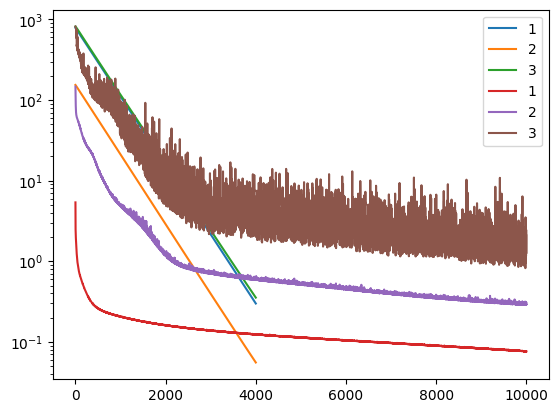

In [10]:
plt.semilogy(metrics_history_smw_11['train_loss'])
plt.semilogy(metrics_history_smw_22['train_loss'])
plt.semilogy(metrics_history_smw_33['train_loss'])

plt.semilogy(metrics_history_sgd_11['train_loss'])
plt.semilogy(metrics_history_sgd_22['train_loss'])
plt.semilogy(metrics_history_sgd_33['train_loss'])

plt.legend(['1', '2', '3', '1', '2', '3'])
plt.show()


<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/jc/hbh56n2114d44h5k85mrw9sr003gz4/T/ipykernel_75518/1879566873.py:15: SyntaxWarning: invalid escape sequence '\m'
  subfigs[1].set_title(f'LM $\mu=0.1$')


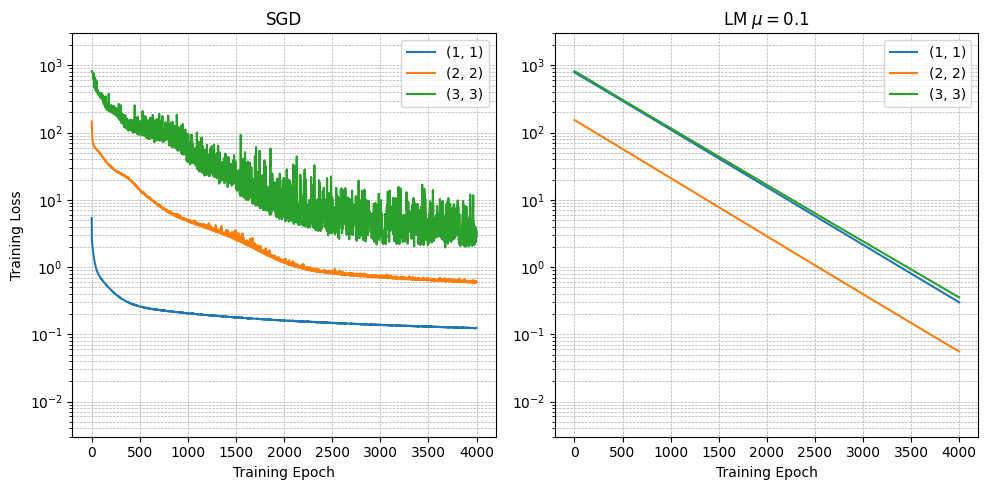

In [11]:
# Create subfigures
fig, subfigs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row

subfigs[0].semilogy(
    metrics_history_sgd_11['train_loss'][0:4000], alpha=1)  # Use alpha for transparency
subfigs[0].semilogy(metrics_history_sgd_22['train_loss'][0:4000], alpha=1)  # Use alpha for transparency
subfigs[0].semilogy(metrics_history_sgd_33['train_loss'][0:4000], alpha=1)  # Use alpha for transparency

subfigs[1].semilogy(metrics_history_smw_11['train_loss'], alpha=1)  # Use alpha for transparency
subfigs[1].semilogy(metrics_history_smw_22['train_loss'], alpha=1)  # Use alpha for transparency
subfigs[1].semilogy(metrics_history_smw_33['train_loss'], alpha=1)  # Use alpha for transparency


subfigs[0].set_title(f'SGD')
subfigs[1].set_title(f'LM $\mu=0.1$')
subfigs[0].set_xlabel('Training Epoch')
subfigs[1].set_xlabel('Training Epoch')
subfigs[0].set_ylabel('Training Loss')
subfigs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[0].set_ylim(3e-3, 3e3)
subfigs[1].set_ylim(3e-3, 3e3)
subfigs[0].legend(['(1, 1)', '(2, 2)', '(3, 3)'], 
                  loc='upper right')  # Place legend outside, , bbox_to_anchor=(1.2, 1)
subfigs[1].legend(['(1, 1)', '(2, 2)', '(3, 3)'], 
                  loc='upper right')  # Place legend outside, , bbox_to_anchor=(1.2, 1)

plt.tight_layout()
plt.savefig('pinns.png')
plt.show()

In [12]:
model = MLP_1D(
    1, dims
)

lr = 1e-2
state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-2,
    # method='gn-exact', epoch=0
)

n, m = 1, 1
state, metrics_history_smw_1e2_11 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=2000,
                                     lm_schedule=lm_info,
                                     forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                         m * jnp.pi * x[1]),
                                     batch_size=100
                                     )

model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

n, m = 2, 2
state, metrics_history_smw_1e2_22 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=2000,
                                     lm_schedule=lm_info,
                                     forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                        m * jnp.pi * x[1]),
                                     batch_size=100
                                     )

model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

n, m = 3, 3
state, metrics_history_smw_1e2_33 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=2000,
                                     lm_schedule=lm_info,
                                     forcing_function=lambda x: (n ** 2 + m ** 2)  * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                         m * jnp.pi * x[1]),
                                     batch_size=100
                                     )


  0%|                                                                                                            | 0/2000 [00:00<?, ?it/s]

(80, 2) (20, 2)
Running smw


  0%|                                                                                                            | 0/2000 [00:00<?, ?it/s]

(80, 2) (20, 2)
Running smw


  0%|                                                                                                            | 0/2000 [00:00<?, ?it/s]

(80, 2) (20, 2)
Running smw


100%|████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [04:39<00:00,  7.16it/s, loss=0.7978]


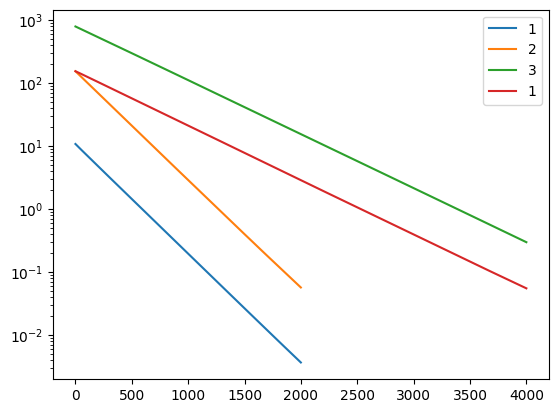

In [13]:
plt.semilogy(metrics_history_smw_1e2_11['train_loss'])
plt.semilogy(metrics_history_smw_1e2_22['train_loss'])
# plt.semilogy(metrics_history_smw_1e2_33['train_loss'])

plt.semilogy(metrics_history_smw_11['train_loss'])
plt.semilogy(metrics_history_smw_22['train_loss'])
# plt.semilogy(metrics_history_smw_33['train_loss'])

# plt.semilogy(metrics_history_sgd_11['train_loss'])
# plt.semilogy(metrics_history_sgd_22['train_loss'])
# plt.semilogy(metrics_history_sgd_33['train_loss'])

plt.legend(['1', '2', '3', '1', '2', '3'])
plt.show()


In [14]:
model = MLP_1D(
    1, dims
)

lr = 5e-3
state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

lm_info = PrecondData(
    # method='smw',epoch=0, lamb=1e-1,
    method='gn-exact', epoch=0, thresh=1e-3
)

# n, m = 1, 1
# state, metrics_history_gn_11 = train_model(state,
#                                      (interior_points, boundary_points),
#                                      num_iterations=5000,
#                                      lm_schedule=lm_info,
#                                      forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
#                                          m * jnp.pi * x[1]),
#                                      batch_size=100
#                                      )
# 
# model = MLP_1D(
#     1, dims
# )
# 
# state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))
# 
# n, m = 2, 2
# state, metrics_history_gn_22 = train_model(state,
#                                      (interior_points, boundary_points),
#                                      num_iterations=5000,
#                                      lm_schedule=lm_info,
#                                      forcing_function=lambda x: (n ** 2 + m ** 2) * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
#                                         m * jnp.pi * x[1]),
#                                      batch_size=100
#                                      )

model = MLP_1D(
    1, dims
)

state = create_train_state(model, learning_rate=lr, momentum=0, optimizer='sgd', shape=jnp.ones((1, 2)))

n, m = 3, 3
state, metrics_history_gn_33 = train_model(state,
                                     (interior_points, boundary_points),
                                     num_iterations=5000,
                                     lm_schedule=lm_info,
                                     forcing_function=lambda x: (n ** 2 + m ** 2)  * jnp.pi * jnp.sin(n * jnp.pi * x[0]) * jnp.sin(
                                         m * jnp.pi * x[1]),
                                     batch_size=100
                                     )


  0%|                                                                                                            | 0/5000 [00:00<?, ?it/s]

(80, 2) (20, 2)
Running gn-exact


100%|███████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [12:33<00:00,  6.64it/s, loss=nan]


In [15]:
plt.semilogy(metrics_history_gn_11['train_loss'])
plt.semilogy(metrics_history_gn_22['train_loss'])
plt.semilogy(metrics_history_gn_33['train_loss'])

# plt.semilogy(metrics_history_sgd_11['train_loss'])
# plt.semilogy(metrics_history_sgd_22['train_loss'])
# plt.semilogy(metrics_history_sgd_33['train_loss'])

plt.legend(['1', '2', '3', '1', '2', '3'])
plt.show()


NameError: name 'metrics_history_gn_11' is not defined